In [7]:
import numpy as np
import pandas as pd
import warnings
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import  train_test_split

In [8]:
x = pd.read_csv("mean_x")
y = pd.read_csv("mean_y")

In [9]:
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y)


In [10]:
x_train

,ПОЛ в плазме,ПОЛ в мембр. Эритроцитов,Лактат,Глюкоза,Общий белок,Мочевина,Кортизол,Зонулин,Холестерин,ЭХС,...,ЭХ_x,ТГ_y,НеЖК,ХЛ,ФЛ_y,ФЛ,СХ_y,СЖК,ТГ,ЭХ_y
61,2.00,5.800000,77.000000,7.700000,5.300,2.560000,30.769231,230.000000,0.197000,22.0,...,12.550000,17.370000,46.790000,11.660000,11.630000,11.925735,19.081912,22.808235,24.416029,24.114265
29,1.53,25.641026,6.800000,9.300000,60.000,14.700000,301.800000,0.289000,2.000000,16.0,...,17.850000,24.650000,31.540000,15.140000,10.820000,13.610000,19.060000,21.970000,22.710000,22.660000
68,1.03,25.641026,29.622619,6.827381,39.155,7.063651,248.718361,95.402933,2.504494,14.0,...,14.920000,16.940000,27.660000,15.870000,24.610000,14.180000,13.600000,23.470000,23.400000,25.360000
70,1.03,30.769231,6.000000,4.800000,60.000,5.600000,435.160000,0.292000,5.500000,16.0,...,22.960000,27.620000,24.940000,10.960000,13.520000,27.280000,28.820000,21.290000,13.010000,9.610000
14,2.05,28.205128,7.600000,8.000000,41.500,15.260000,361.280000,0.370714,4.900000,13.0,...,26.050000,21.960000,15.340000,19.040000,17.610000,14.280000,19.040000,23.000000,23.000000,23.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51,2.00,5.300000,75.200000,5.500000,3.300,1.530000,30.769231,235.416667,0.272000,14.0,...,17.240000,23.120000,22.860000,19.840000,16.940000,11.925735,19.081912,22.808235,24.416029,24.114265
85,2.00,5.300000,75.200000,4.900000,5.800,1.030000,29.487179,270.000000,0.211000,19.0,...,20.010000,19.720000,26.320000,12.870000,21.080000,7.880000,20.810000,14.050000,19.340000,37.920000
37,1.03,24.358974,29.622619,6.827381,39.155,7.063651,248.718361,95.402933,2.504494,13.0,...,18.007976,23.350714,30.425357,14.334524,13.882143,15.560000,19.880000,29.380000,28.710000,24.360000
46,3.08,30.769231,6.000000,4.800000,60.000,5.600000,435.160000,0.292000,5.500000,24.0,...,22.960000,20.500000,20.150000,16.350000,20.040000,21.140000,22.610000,27.650000,17.510000,11.100000


In [11]:
clf = DecisionTreeClassifier(random_state = 42,class_weight= {0: 1, 1: 6},max_depth = 2)
clf.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 1, 1: 6}"


In [15]:
prediction = clf.predict(x_test)
accuracy_score(prediction, y_test)

0.9655172413793104

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

In [16]:
print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
print(f"Precision:{precision_score(y_test, prediction):.3f}")
print(f"Recall:  {recall_score(y_test, prediction):.3f}")
print(f"F1-score: {f1_score(y_test, prediction):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
print("\nClassification Report:\n", classification_report(y_test, prediction))

Accuracy:0.966
Precision:1.000
Recall:  0.800
F1-score: 0.889

Confusion Matrix:
 [[24  0]
 [ 1  4]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        24
         1.0       1.00      0.80      0.89         5

    accuracy                           0.97        29
   macro avg       0.98      0.90      0.93        29
weighted avg       0.97      0.97      0.96        29



In [17]:
from sklearn.model_selection import cross_val_score


scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")


F1-результаты по фолдам: [1.         0.8        0.8        0.85714286 1.        ]
Средний F1: 0.89


In [26]:
clf = RandomForestClassifier(n_estimators=100,random_state = 42,class_weight= {0: 1, 1: 6},max_depth = 2)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_pred, y_test)

c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


1.0

In [27]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:1.000
Precision:1.000
Recall:  1.000
F1-score: 1.000

Confusion Matrix:
 [[24  0]
 [ 0  5]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        24
         1.0       1.00      1.00      1.00         5

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29



In [28]:
from sklearn.model_selection import cross_val_score


scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")

c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


F1-результаты по фолдам: [1.         0.85714286 1.         0.75       1.        ]
Средний F1: 0.92


c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [22]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    n_estimators=120,
    max_depth=2,
    random_state=42
)

# Создаем веса для каждой строки обучающей выборки
weights = y_train.iloc[:, 0].map({0: 1, 1: 6})


clf.fit(x_train, y_train, sample_weight=weights)
y_pred = clf.predict(x_test)
accuracy_score(y_pred, y_test)

c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.9655172413793104

In [23]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.966
Precision:1.000
Recall:  0.800
F1-score: 0.889

Confusion Matrix:
 [[24  0]
 [ 1  4]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        24
         1.0       1.00      0.80      0.89         5

    accuracy                           0.97        29
   macro avg       0.98      0.90      0.93        29
weighted avg       0.97      0.97      0.96        29



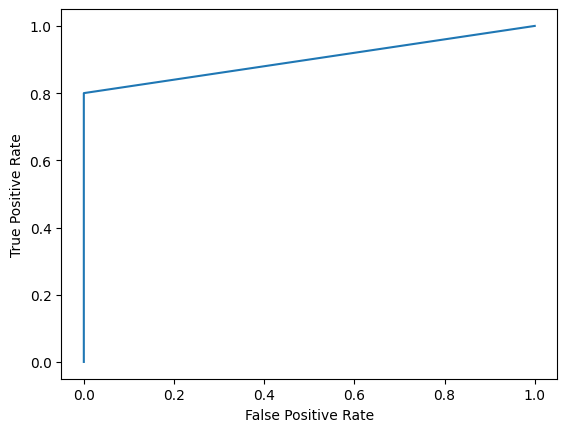

In [24]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)

# построение ROC кривой
plt.plot(fpr, tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score


scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")

c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A colu

F1-результаты по фолдам: [1.  0.8 0.8 1.  1. ]
Средний F1: 0.92


c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
